# KMeans Clustering
# E-Commerce Customer Behavior and Sales Analysis

## Project Overview

In today’s e-commerce industry, understanding customer behavior is one of the most important factors for improving business performance, increasing revenue, and building effective marketing strategies. Companies generate massive amounts of transactional and behavioral data every day, but transforming this raw data into actionable insights requires advanced data analysis and machine learning techniques.

This project focuses on analyzing the **E-Commerce Customer Behavior and Sales Analysis TR** dataset to discover hidden customer patterns, purchasing behaviors, and engagement characteristics using **unsupervised machine learning techniques**, particularly **Customer Segmentation with Clustering**.

The main objective of this project is to identify different types of customers based on:

* Purchasing behavior
* Spending patterns
* Order frequency
* Customer engagement
* Website interaction
* Customer satisfaction

To achieve this, the project applies a complete data science workflow including:

* Data Cleaning and Preprocessing
* Exploratory Data Analysis
* Feature Engineering
* Customer-Level Aggregation
* Scaling and Transformation Techniques
* Clustering Analysis using K-Means
* Cluster Evaluation Metrics
* Customer Cohort Analysis and Segmentation

Several clustering experiments were conducted using different preprocessing strategies, feature combinations, scalers, and numbers of clusters. The project compares these experiments using multiple evaluation metrics such as:

* Silhouette Score
* Davies-Bouldin Score
* Calinski-Harabasz Score

A major focus of this project is separating customers into two important dimensions:

1. **Customer Value**

   * Total spending
   * Order frequency
   * Average order value

2. **Customer Engagement**

   * Session duration
   * Pages viewed
   * Customer ratings

This approach allows the creation of highly meaningful customer segments that can help businesses:

* Improve customer retention
* Design personalized marketing campaigns
* Identify high-value customers
* Detect low-engagement customers
* Optimize sales strategies
* Increase customer satisfaction

By the end of this project, the dataset is transformed into a powerful customer intelligence framework that provides clear business insights and actionable segmentation strategies for real-world e-commerce applications.

---

## Dataset

The dataset used in this project is E-Commerce Customer Behavior & Sales dataset
Dataset Source:  
[E-Commerce Customer Behavior & Sales Analysis -TR Dataset](https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr)

---

## Project Goal

The primary goal of this project is to build a robust customer segmentation system that groups customers based on both purchasing power and engagement behavior in order to generate meaningful business insights and support data-driven decision-making.

---

## Technologies and Libraries Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn

---

## Machine Learning Technique

* Unsupervised Learning

  * K-Means Clustering

---

## Evaluation Metrics

* Silhouette Score
* Davies-Bouldin Score
* Calinski-Harabasz Score

---

## Final Outcome

The final clustering framework successfully identifies multiple customer segments by combining customer value analysis with engagement analysis, enabling deeper understanding of customer behavior and supporting advanced business and marketing strategies.


# **Importing the Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# **Data preprocessing**

## Data Cleaning Check Template
This template is designed to quickly assess the quality of any dataset before building machine learning models or performing analysis.

It provides a structured overview of the dataset by checking for common data issues such as:

- Missing values

- Duplicate rows

- Incorrect data types

- Outliers

- Distribution of numerical features

- Categorical feature consistency

**What This Template Does**

- Displays basic dataset information (shape, data types)

- Identifies missing values and duplicates

- Summarizes numerical and categorical features

- Detects potential outliers using the IQR method

- Highlights columns with low unique values for quick inspection

How to Use

1. Load your dataset using Pandas  

2. Call the function:

In [2]:
def data_quality_report(df):

    print("DATA QUALITY REPORT")
    
    # Print a separator line for better readability
    
    print("=" * 50)
    print("BASIC INFO")
    print("=" * 50)
    
    # Show general information about the dataset (columns, data types, non-null values)
    print(df.info())
    
    # Show number of rows and columns
    print("\n" + "=" * 50)
    print("SHAPE OF DATA")
    print("=" * 50)
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Check for missing (null) values in each column
    print("\n" + "=" * 50)
    print("MISSING VALUES")
    print("=" * 50)
    missing = df.isnull().sum()
    
    # Display only columns that have missing values
    print(missing[missing > 0])
    
    # Check for duplicate rows
    print("\n" + "=" * 50)
    print("DUPLICATES")
    print("=" * 50)
    print(f"Duplicate rows: {df.duplicated().sum()}")
    
    # Display data types of each column
    print("\n" + "=" * 50)
    print("DATA TYPES")
    print("=" * 50)
    print(df.dtypes)
    
    # Summary statistics for numerical columns (mean, std, min, max, etc.)
    print("\n" + "=" * 50)
    print("NUMERICAL SUMMARY")
    print("=" * 50)
    print(df.describe())
    
    # Summary for categorical (object) columns
    print("\n" + "=" * 50)
    print("CATEGORICAL SUMMARY")
    print("=" * 50)
    print(df.describe(include=['object']))
    
    # Show unique values for columns with low number of distinct values
    # Useful for detecting categories, errors, or inconsistencies
    print("\n" + "=" * 50)
    print("UNIQUE VALUES (LOW CARDINALITY)")
    print("=" * 50)
    for col in df.columns:
        if df[col].nunique() < 10:  # Only show columns with few unique values
            print(f"{col}: {df[col].unique()}")
            
    # correlation
    print("\n" + "=" * 50)
    print("CORRELATION MATRIX")
    print("=" * 50)
    print(df.corr(numeric_only=True))
    
    # Detect outliers using the IQR (Interquartile Range) method
    print("\n" + "=" * 50)
    print("OUTLIERS CHECK (IQR METHOD)")
    print("=" * 50)
    
    # Loop through only numerical columns
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)  # 25th percentile
        Q3 = df[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        
        # Count rows that fall outside the normal range
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        print(f"{col}: {len(outliers)} outliers")

# **Load dataset**
Apply Data Cleaning Check Template

In [ ]:
dataset = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")
data_quality_report(dataset)

DATA QUALITY REPORT
BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  1704

# **Outlier Analysis**
Outlier detection was performed using the IQR method on the numerical features.

### Features with Detected Outliers

- `Age`
- `Unit_Price`
- `Discount_Amount`
- `Total_Amount`
- `Session_Duration_Minutes`
- `Pages_Viewed`
- `Delivery_Time_Days`


### Age: 50 outliers

In [4]:
# Calculate fences for year
Q1 = dataset['Age'].quantile(0.25)
Q3 = dataset['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the dataframe to show ONLY the outliers
Age = dataset[(dataset['Age'] < lower_fence) | (dataset['Age'] > upper_fence)]

# Display the rows
print(Age)

           Order_ID Customer_ID        Date  Age  Gender       City  \
585    ORD_000180-1  CUST_00180  2023-03-14   67    Male    Antalya   
586    ORD_000180-2  CUST_00180  2023-04-27   67    Male    Antalya   
587    ORD_000180-3  CUST_00180  2024-01-01   67    Male    Antalya   
588    ORD_000180-4  CUST_00180  2024-03-20   67    Male    Antalya   
691    ORD_000210-1  CUST_00210  2023-02-15   75    Male      Izmir   
692    ORD_000210-2  CUST_00210  2023-08-06   75    Male      Izmir   
693    ORD_000210-3  CUST_00210  2023-12-09   75    Male      Izmir   
694    ORD_000210-4  CUST_00210  2024-01-07   75    Male      Izmir   
695    ORD_000210-5  CUST_00210  2024-01-29   75    Male      Izmir   
696    ORD_000210-6  CUST_00210  2024-03-13   75    Male      Izmir   
1573   ORD_000479-1  CUST_00479  2023-10-01   71    Male   Istanbul   
5593   ORD_001616-1  CUST_01616  2023-07-05   73    Male  Gaziantep   
6731   ORD_001958-1  CUST_01958  2023-12-26   72    Male   Istanbul   
7004  

In [5]:
print(dataset["Age"])

0        40
1        40
2        40
3        33
4        33
         ..
17044    44
17045    24
17046    24
17047    24
17048    24
Name: Age, Length: 17049, dtype: int64


### Unit_Price: 1757 outliers

In [6]:
# Calculate fences for year
Q1 = dataset['Unit_Price'].quantile(0.25)
Q3 = dataset['Unit_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the dataframe to show ONLY the outliers
Unit_Price = dataset[(dataset['Unit_Price'] < lower_fence) | (dataset['Unit_Price'] > upper_fence)]

# Display the rows
print(Unit_Price)

           Order_ID Customer_ID        Date  Age  Gender      City  \
16     ORD_000008-2  CUST_00008  2023-10-07   44  Female     Konya   
35     ORD_000015-1  CUST_00015  2023-02-13   18    Male    Ankara   
37     ORD_000015-3  CUST_00015  2023-08-20   18    Male    Ankara   
83     ORD_000029-7  CUST_00029  2023-12-29   27    Male  Istanbul   
84     ORD_000029-8  CUST_00029  2024-03-25   27    Male  Istanbul   
...             ...         ...         ...  ...     ...       ...   
17012  ORD_004990-3  CUST_04990  2023-11-13   63    Male  Istanbul   
17017  ORD_004992-2  CUST_04992  2024-02-08   43    Male  Istanbul   
17020  ORD_004993-3  CUST_04993  2023-03-03   33  Female     Adana   
17026  ORD_004993-9  CUST_04993  2024-03-17   33  Female     Adana   
17040  ORD_004997-2  CUST_04997  2023-03-15   43  Female     Adana   

      Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
16              Sports     1197.86         4             0.00       4791.44   
3

In [7]:
print(dataset["Unit_Price"])

0          29.18
1         644.40
2         332.82
3          69.30
4         178.15
          ...   
17044      68.65
17045     156.12
17046    1065.24
17047      47.73
17048    1015.23
Name: Unit_Price, Length: 17049, dtype: float64


### Discount_Amount: 2789 outliers

In [9]:
# 1. Calculate IQR for Discount_Amount to find statistical outliers
Q1 = dataset['Discount_Amount'].quantile(0.25)
Q3 = dataset['Discount_Amount'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Filter the dataframe to isolate ONLY the Discount_Amount outliers
# (Usually, discounts are only outliers on the upper side, but we will check both)
outlier_mask = (dataset['Discount_Amount'] < lower_bound) | (dataset['Discount_Amount'] > upper_bound)
df_outliers = dataset[outlier_mask].copy()

# 3. Apply your business rule to the outliers
# A discount is VALID if it is less than or equal to total price
valid_mask = df_outliers['Discount_Amount'] <= (df_outliers['Unit_Price'] * df_outliers['Quantity'])

# Separate into Valid and Invalid DataFrames
df_valid_outliers = df_outliers[valid_mask]
df_invalid_outliers = df_outliers[~valid_mask]

# --- RESULTS AND OUTPUTS ---

# 4. Show counts of valid vs invalid outliers
print("=== OUTLIER ANALYSIS SUMMARY ===")
print(f"Total Statistical Outliers Found: {len(df_outliers)}")
print(f"Valid Outliers (Passed Business Rule): {len(df_valid_outliers)}")
print(f"Invalid Outliers (Failed Business Rule): {len(df_invalid_outliers)}")
print("-" * 40)

# 5. Show ALL invalid data from the Discount_Amount column
print("\n=== ALL INVALID DISCOUNT OUTLIERS ===")
if not df_invalid_outliers.empty:
    # Displaying key columns for verification
    print(df_invalid_outliers[['Discount_Amount', 'Unit_Price', 'Quantity']])
else:
    print("Great news! Zero invalid discounts found among the outliers.")

=== OUTLIER ANALYSIS SUMMARY ===
Total Statistical Outliers Found: 2789
Valid Outliers (Passed Business Rule): 2789
Invalid Outliers (Failed Business Rule): 0
----------------------------------------

=== ALL INVALID DISCOUNT OUTLIERS ===
Great news! Zero invalid discounts found among the outliers.


In [10]:
print(dataset["Discount_Amount"])

0          0.00
1        138.05
2          0.00
3         71.05
4          0.00
          ...  
17044      0.00
17045      0.00
17046      0.00
17047      8.80
17048    217.01
Name: Discount_Amount, Length: 17049, dtype: float64


### Total_Amount: 1943 outliers

In [12]:
# 1. Calculate IQR for Total_Amount to find statistical outliers
Q1 = dataset['Total_Amount'].quantile(0.25)
Q3 = dataset['Total_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Isolate the Total_Amount outliers
outlier_mask = (dataset['Total_Amount'] < lower_bound) | (dataset['Total_Amount'] > upper_bound)
df_outliers = dataset[outlier_mask].copy()

# 3. Calculate what the Total Amount SHOULD be
expected_total = (df_outliers['Unit_Price'] * df_outliers['Quantity']) - df_outliers['Discount_Amount']

# 4. Check business logic (allowing a 1-cent variance for rounding errors)
# A row is VALID if the actual Total_Amount closely matches the expected_total
valid_mask = (df_outliers['Total_Amount'] - expected_total).abs() <= 0.01

# Separate into Valid and Invalid DataFrames
df_valid_outliers = df_outliers[valid_mask]
df_invalid_outliers = df_outliers[~valid_mask]

# --- RESULTS AND OUTPUTS ---

print("=== TOTAL_AMOUNT OUTLIER ANALYSIS ===")
print(f"Total Statistical Outliers Found: {len(df_outliers)}")
print(f"Valid Outliers (Math matches formula): {len(df_valid_outliers)}")
print(f"Invalid Outliers (Math fails formula): {len(df_invalid_outliers)}")
print("-" * 40)

print("\n=== ALL INVALID TOTAL_AMOUNT OUTLIERS ===")
if not df_invalid_outliers.empty:
    # Displaying key columns alongside the expected calculation for easy auditing
    df_invalid_outliers['Expected_Total'] = (df_invalid_outliers['Unit_Price'] * df_invalid_outliers['Quantity']) - df_invalid_outliers['Discount_Amount']
    print(df_invalid_outliers[['Total_Amount', 'Expected_Total', 'Unit_Price', 'Quantity', 'Discount_Amount']])
else:
    print("All statistical outliers perfectly follow your equation!")

=== TOTAL_AMOUNT OUTLIER ANALYSIS ===
Total Statistical Outliers Found: 1943
Valid Outliers (Math matches formula): 1943
Invalid Outliers (Math fails formula): 0
----------------------------------------

=== ALL INVALID TOTAL_AMOUNT OUTLIERS ===
All statistical outliers perfectly follow your equation!


In [13]:
print(dataset["Total_Amount"])

0          29.18
1         506.35
2        1664.10
3         275.45
4         534.45
          ...   
17044     137.30
17045     156.12
17046    3195.72
17047      86.66
17048    3843.91
Name: Total_Amount, Length: 17049, dtype: float64


### Session_Duration_Minutes: 85 outliers

In [14]:
# Calculate fences for year
Q1 = dataset['Session_Duration_Minutes'].quantile(0.25)
Q3 = dataset['Session_Duration_Minutes'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the dataframe to show ONLY the outliers
Session_Duration_Minutes = dataset[(dataset['Session_Duration_Minutes'] < lower_fence) | (dataset['Session_Duration_Minutes'] > upper_fence)]

# Display the rows
print(Session_Duration_Minutes)

           Order_ID Customer_ID        Date  Age  Gender       City  \
345    ORD_000110-2  CUST_00110  2023-07-27   34  Female  Gaziantep   
498    ORD_000154-6  CUST_00154  2023-10-15   37  Female      Izmir   
784    ORD_000240-2  CUST_00240  2023-09-24   45  Female   Istanbul   
880    ORD_000264-2  CUST_00264  2023-11-23   22  Female    Antalya   
954    ORD_000289-8  CUST_00289  2024-03-23   38  Female   Istanbul   
...             ...         ...         ...  ...     ...        ...   
15230  ORD_004470-2  CUST_04470  2024-01-17   39    Male   Istanbul   
15795  ORD_004642-1  CUST_04642  2023-01-04   36  Female  Gaziantep   
15837  ORD_004655-1  CUST_04655  2023-01-01   43  Female      Bursa   
16100  ORD_004722-3  CUST_04722  2023-09-17   41  Female  Eskisehir   
16651  ORD_004869-3  CUST_04869  2024-01-29   36  Female  Eskisehir   

      Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
345               Food      111.04         3             0.00       

In [15]:
print(dataset["Session_Duration_Minutes"])

0        14
1        14
2        15
3        16
4        14
         ..
17044    14
17045    15
17046    17
17047    13
17048    15
Name: Session_Duration_Minutes, Length: 17049, dtype: int64


### Pages_Viewed: 1 outliers

In [16]:
# Calculate fences for year
Q1 = dataset['Pages_Viewed'].quantile(0.25)
Q3 = dataset['Pages_Viewed'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the dataframe to show ONLY the outliers
Pages_Viewed = dataset[(dataset['Pages_Viewed'] < lower_fence) | (dataset['Pages_Viewed'] > upper_fence)]

# Display the rows
print(Pages_Viewed)

           Order_ID Customer_ID        Date  Age Gender    City  \
13830  ORD_004078-2  CUST_04078  2023-05-16   18   Male  Ankara   

      Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
13830           Beauty      115.99         3            39.42        308.55   

      Payment_Method Device_Type  Session_Duration_Minutes  Pages_Viewed  \
13830    Credit Card      Mobile                        10            18   

       Is_Returning_Customer  Delivery_Time_Days  Customer_Rating  
13830                   True                  13                5  


In [17]:
print(dataset["Pages_Viewed"])

0         9
1         8
2        10
3        13
4         7
         ..
17044    10
17045     8
17046    11
17047    11
17048     7
Name: Pages_Viewed, Length: 17049, dtype: int64


### Delivery_Time_Days: 475 outliers

In [18]:
# Calculate fences for year
Q1 = dataset['Delivery_Time_Days'].quantile(0.25)
Q3 = dataset['Delivery_Time_Days'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Filter the dataframe to show ONLY the outliers
Delivery_Time_Days = dataset[(dataset['Delivery_Time_Days'] < lower_fence) | (dataset['Delivery_Time_Days'] > upper_fence)]

# Display the rows
print(Delivery_Time_Days)

           Order_ID Customer_ID        Date  Age  Gender       City  \
105    ORD_000037-1  CUST_00037  2023-12-29   37  Female  Gaziantep   
135    ORD_000048-4  CUST_00048  2024-02-02   47    Male    Antalya   
229    ORD_000078-3  CUST_00078  2023-09-04   31    Male   Istanbul   
235    ORD_000080-3  CUST_00080  2023-07-08   18    Male     Ankara   
257    ORD_000087-3  CUST_00087  2023-05-14   45    Male    Kayseri   
...             ...         ...         ...  ...     ...        ...   
16850  ORD_004938-8  CUST_04938  2024-02-16   49    Male    Antalya   
16895  ORD_004952-2  CUST_04952  2023-10-15   50    Male    Antalya   
16953  ORD_004971-4  CUST_04971  2023-11-05   53  Female     Ankara   
16990  ORD_004983-3  CUST_04983  2023-10-07   38    Male   Istanbul   
17028  ORD_004994-2  CUST_04994  2023-03-10   41    Male    Kayseri   

      Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
105      Home & Garden     1199.80         3             0.00       

In [19]:
print(dataset["Delivery_Time_Days"])

0        13
1         6
2         9
3         4
4         6
         ..
17044     6
17045     7
17046     5
17047    12
17048     3
Name: Delivery_Time_Days, Length: 17049, dtype: int64


# **Feature Engineering**
## Customer-Level Feature Engineering

### Aggregating Customer Purchase Behavior

This section creates a customer-level dataset by grouping transactions using `Customer_ID`.
The following features are generated to better understand customer purchasing behavior:

* **Total_Amount** → Total money spent by each customer
* **Quantity** → Total quantity of products purchased
* **Num_Orders** → Total number of orders made by each customer
* **Avg_Order_Value** → Average spending per order for each customer

These features will be useful for customer segmentation, clustering, and behavioral analysis.


In [20]:
customer_df = dataset.groupby('Customer_ID').agg({'Total_Amount':'sum', 'Quantity':'sum', 'Order_ID':'count'})

customer_df.rename(columns={'Order_ID':'Num_Orders'}, inplace=True)

customer_df['Avg_Order_Value'] = (customer_df['Total_Amount'] / customer_df['Num_Orders'])

In [21]:
print(customer_df)

             Total_Amount  Quantity  Num_Orders  Avg_Order_Value
Customer_ID                                                     
CUST_00001        2199.63         7           3       733.210000
CUST_00002         809.90         8           2       404.950000
CUST_00003        3030.81         7           2      1515.405000
CUST_00004         383.22         5           1       383.220000
CUST_00005        2422.73         8           3       807.576667
...                   ...       ...         ...              ...
CUST_04996        3001.96        13           4       750.490000
CUST_04997       15440.42        13           4      3860.105000
CUST_04998         482.90         5           1       482.900000
CUST_04999         137.30         2           1       137.300000
CUST_05000        7282.41        10           4      1820.602500

[5000 rows x 4 columns]


## Customer Engagement Feature Engineering

### Aggregating Behavioral Engagement Metrics

This section builds a customer-level engagement dataset by grouping interactions using `Customer_ID`.
It captures how customers interact with the platform based on their behavior during sessions:

* **Session_Duration_Minutes** → Average time spent per session for each customer
* **Pages_Viewed** → Average number of pages viewed per session
* **Customer_Rating** → Average rating given by each customer

These features help measure customer engagement intensity and satisfaction, and will be useful for clustering and behavioral segmentation.


In [22]:
engagement_df = dataset.groupby('Customer_ID').agg({'Session_Duration_Minutes': 'mean', 'Pages_Viewed': 'mean', 'Customer_Rating': 'mean'})

In [23]:
print(engagement_df)

             Session_Duration_Minutes  Pages_Viewed  Customer_Rating
Customer_ID                                                         
CUST_00001                  14.333333      9.000000         3.333333
CUST_00002                  15.000000     10.000000         4.000000
CUST_00003                  10.500000      8.500000         3.500000
CUST_00004                  16.000000     15.000000         5.000000
CUST_00005                  12.666667      9.333333         3.666667
...                               ...           ...              ...
CUST_04996                  14.750000      7.500000         3.000000
CUST_04997                  15.500000     11.250000         4.000000
CUST_04998                   9.000000      8.000000         3.000000
CUST_04999                  14.000000     10.000000         1.000000
CUST_05000                  15.000000      9.250000         3.750000

[5000 rows x 3 columns]


# **Select Independent Variable (X)**

Note: The concepts of Independent and Dependent variables were discussed earlier.

If you would like to review or gain a clearer understanding, please refer to this section: [Go to Independent variable VS Dependent variable Section](https://github.com/Hazem1695/ml-concept-briefs)

### `customer_df`

In [24]:
X = customer_df.iloc[:,:].values

In [25]:
print(X[0:1,:])

[[2199.63    7.      3.    733.21]]


In [26]:
print(f"Rows: {X.shape[0]}, Columns: {X.shape[1]}")

Rows: 5000, Columns: 4


### `engagement_df`

In [27]:
X_2 = engagement_df.iloc[:,:].values

In [28]:
print(X_2[0:1,:])

[[14.33333333  9.          3.33333333]]


In [29]:
print(f"Rows: {X_2.shape[0]}, Columns: {X_2.shape[1]}")

Rows: 5000, Columns: 3


# **Feature Scaling**

Note: I explained Feature Scaling earlier.

If you want to understand when and why to use feature scaling, you can check it here: [Go to StandardScaler vs RobustScaler Section](https://github.com/Hazem1695/ml-concept-briefs)

### Feature Scaling Using StandardScaler with `customer_df`

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

### Feature Scaling Using RobustScaler with `engagement_df`

In [31]:
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
X_2 = rs.fit_transform(X_2)

In [32]:
print(X[0:10, :])

[[-0.40883062 -0.45941456 -0.18784999 -0.34419487]
 [-0.67233554 -0.31884343 -0.64624431 -0.55750511]
 [-0.25123165 -0.45941456 -0.64624431  0.16409186]
 [-0.75323779 -0.74055681 -1.10463864 -0.57162572]
 [-0.36652891 -0.31884343 -0.18784999 -0.29586985]
 [-0.58967941 -0.1782723  -0.18784999 -0.55079463]
 [-0.57342615 -0.74055681 -1.10463864  0.04461902]
 [ 0.23634337 -0.59998568 -0.18784999  0.39284509]
 [-0.73662048 -1.16227019 -1.10463864 -0.51467541]
 [-0.55643532 -0.03770118 -0.18784999 -0.51281692]]


In [33]:
print(X_2[0:10, :])

[[-0.07073386  0.         -0.66666667]
 [ 0.21220159  0.5         0.        ]
 [-1.69761273 -0.25       -0.5       ]
 [ 0.63660477  3.          1.        ]
 [-0.7780725   0.16666667 -0.33333333]
 [ 0.63660477  0.16666667  0.33333333]
 [ 1.06100796  0.          0.        ]
 [ 1.06100796  0.          0.66666667]
 [-1.48541114  1.         -1.        ]
 [-0.07073386  0.          0.        ]]


# **Elbow method** 

### Elbow method with `customer_df`


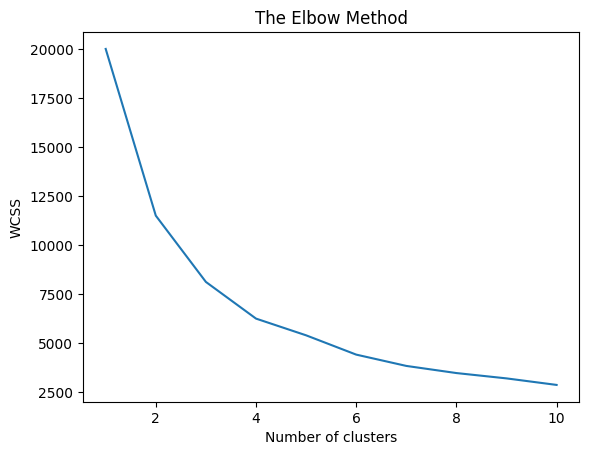

In [34]:
from sklearn.cluster import KMeans
wcss = []
# try diffirent number of clusters from 1 to 10
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  # next step is to run the algorithm(train it with i number of cluster)
  kmeans.fit(X)
  # get the wscc value
  wcss.append(kmeans.inertia_)

# plot hte elbow
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Elbow method with `engagement_df`

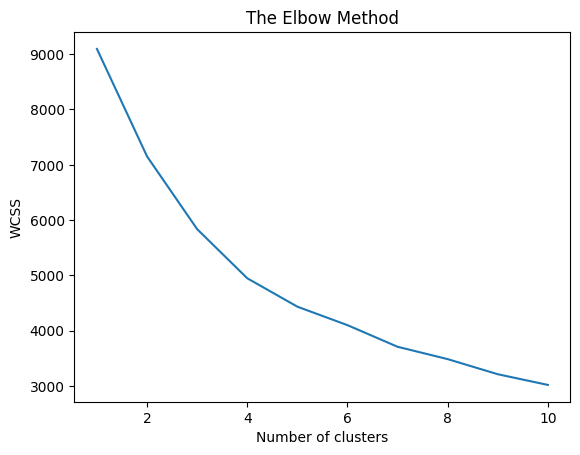

In [35]:
from sklearn.cluster import KMeans
wcss = []
# try diffirent number of clusters from 1 to 10
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  # next step is to run the algorithm(train it with i number of cluster)
  kmeans.fit(X_2)
  # get the wscc value
  wcss.append(kmeans.inertia_)

# plot hte elbow
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# **Building Kmeans Clustering Model**

## Training the Building Kmeans Clustering model on the dataset


## Customer Purchase Behavior Clustering (K-Means)

### Applying K-Means on Customer Transaction Features

In this section, K-Means clustering is applied to the **customer purchase behavior dataset (`customer_df`)** to group customers based on their spending patterns.

* Model: **KMeans (k = 3)**
* Features used: Purchase-based metrics (e.g., total spending, number of orders, average order value)
* Purpose: Identify distinct customer segments based on purchasing behavior

In [36]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

## Customer Engagement Clustering (K-Means)

### Applying K-Means on Customer Interaction Features

In this section, K-Means clustering is applied to the **customer engagement dataset (`engagement_df`)** to segment customers based on their interaction behavior on the platform.

* Model: **KMeans (k = 4)**
* Features used: Engagement metrics (e.g., session duration, pages viewed, customer rating)
* Purpose: Discover different levels of customer engagement and activity patterns


In [37]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans_2 = kmeans.fit_predict(X_2)

In [38]:
print(y_kmeans)

[1 1 1 ... 1 1 1]


In [39]:
print(y_kmeans_2)

[1 3 0 ... 0 1 3]


# **Evaluating the Model Performance**

## Customer Purchase Clustering Evaluation

### Evaluating K-Means Clusters on Transaction Behavior

This section evaluates the performance of the K-Means clustering model applied to **customer purchase behavior (`customer_df`)** using multiple clustering metrics:

* **Silhouette Score** → Measures how well clusters are separated and how similar points are within clusters
* **Davies-Bouldin Index** → Measures cluster similarity (lower values indicate better clustering)
* **Calinski-Harabasz Score** → Measures cluster separation and compactness (higher values indicate better clustering)

These metrics help validate the quality and structure of the customer segments derived from purchasing behavior.

In [40]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_kmeans)
print("silhouette score")
print(score)

from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(X, y_kmeans)
print("davies bouldin score")
print(dbi)

from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(X, y_kmeans)
print("calinski harabasz score")
print(ch)

silhouette score
0.5119247871902031
davies bouldin score
0.8928545162569859
calinski harabasz score
3662.7984802400138


## Customer Engagement Clustering Evaluation

### Evaluating K-Means Clusters on Behavioral Engagement

This section evaluates the K-Means clustering model applied to **customer engagement behavior (`engagement_df`)** using standard clustering validation metrics:

* **Silhouette Score** → Indicates how well-separated engagement clusters are
* **Davies-Bouldin Index** → Evaluates similarity between clusters (lower is better)
* **Calinski-Harabasz Score** → Measures cluster density and separation (higher is better)

These results help assess how effectively customers are grouped based on their interaction and engagement patterns.


In [41]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_2, y_kmeans_2)
print("silhouette score")
print(score)

from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(X_2, y_kmeans_2)
print("davies bouldin score")
print(dbi)

from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(X_2, y_kmeans_2)
print("calinski harabasz score")
print(ch)

silhouette score
0.2181406082712162
davies bouldin score
1.2296503552913518
calinski harabasz score
1395.154297048095


## Combining Customer Value and Engagement Segments

### Creating a Unified Customer Segmentation Matrix

In this section, we combine the results of two independent K-Means models:

* **Value Clusters** → Based on customer purchasing behavior (`customer_df`)
* **Engagement Clusters** → Based on customer interaction behavior (`engagement_df`)

Each customer is assigned both a value segment and an engagement segment, allowing us to analyze how spending behavior aligns with platform activity.

In [42]:
customer_df["Value_Cluster"] = y_kmeans

engagement_df["Engagement_Cluster"] = y_kmeans_2

### Merging Cluster Results

The two clustering outputs are merged using `Customer_ID` to create a unified segmentation dataset:

* **Value_Cluster** → Customer spending-based segment
* **Engagement_Cluster** → Customer behavior-based segment

This enables a cross-dimensional view of customer profiles.

---

### Building the Revenue vs Engagement Matrix

A cross-tabulation table is created to summarize the relationship between the two clustering results:

* Rows → Value-based customer segments
* Columns → Engagement-based customer segments
* Values → Number of customers in each combination

This matrix helps identify key customer groups such as:

* High value + high engagement customers
* High value + low engagement customers
* Low value + high engagement customers
* Low value + low engagement customers

These insights are useful for targeted marketing and customer strategy optimization.


In [ ]:
# Merge the two independent cluster insights together
final_matrix_df = pd.merge(customer_df[["Value_Cluster"]], engagement_df[["Engagement_Cluster"]], on="Customer_ID",)

# Show the cross-tabulation table counts
final_matrix = pd.crosstab(final_matrix_df["Value_Cluster"], final_matrix_df["Engagement_Cluster"], margins=True,)

print("=== FINAL REVENUE VS ENGAGEMENT GRID ===")
print(final_matrix)

=== FINAL REVENUE VS ENGAGEMENT GRID ===
Engagement_Cluster     0    1     2     3   All
Value_Cluster                                  
0                    385  196   272   336  1189
1                    964  700   829   983  3476
2                     94   76    60   105   335
All                 1443  972  1161  1424  5000


## Creating Combined Customer Segments (Value + Engagement)

### Generating Unified Customer Labels

In this section, a new segmentation label is created by combining both clustering results:

* **Value_Cluster (V)** → Customer spending behavior segment
* **Engagement_Cluster (E)** → Customer interaction behavior segment

Each customer is assigned a **combined segment label** in the format:

* `V{Value_Cluster}_E{Engagement_Cluster}`

  * Example: `V0_E3`, `V2_E1`, etc.

---

### Purpose of Combined Segments

This unified labeling allows a more detailed understanding of customers by merging:

* How much they spend (Value)
* How actively they engage (Engagement)

It helps in identifying meaningful personas such as:

* High-value highly engaged customers
* High-value low-engagement customers
* Low-value but highly engaged users
* Low-value inactive users

These combined segments are useful for deeper customer profiling, targeted marketing strategies, and business decision-making.


In [ ]:
# Create the combined segment column using the correct dataframe name
final_matrix_df['Segment'] = ("V" + final_matrix_df['Value_Cluster'].astype(str) + "_E" + final_matrix_df['Engagement_Cluster'].astype(str))

# View the first few rows to see your clean new labels (e.g., V0_E3, V2_E1)
print(final_matrix_df.head(100))

             Value_Cluster  Engagement_Cluster Segment
Customer_ID                                           
CUST_00001               1                   1   V1_E1
CUST_00002               1                   3   V1_E3
CUST_00003               1                   0   V1_E0
CUST_00004               1                   3   V1_E3
CUST_00005               1                   0   V1_E0
...                    ...                 ...     ...
CUST_00096               1                   2   V1_E2
CUST_00097               1                   0   V1_E0
CUST_00098               1                   2   V1_E2
CUST_00099               2                   3   V2_E3
CUST_00100               1                   2   V1_E2

[100 rows x 3 columns]


## Customer Segment Profiling Analysis

### Building a Unified Analysis Dataset

In this section, we merge all customer-level information into a single dataset:

* **Customer Purchase Behavior (`customer_df`)**
* **Customer Engagement Behavior (`engagement_df`)**
* **Combined Segment Label (`Segment`)**

This creates a complete view of each customer combining both value and engagement dimensions.

---

### Segment-Level Behavioral Profiling

The data is then grouped by the combined segment labels (e.g., `V0_E3`, `V2_E1`) to compute average behavioral characteristics:

For each segment, we calculate:

* **Total_Amount** → Average customer spending
* **Num_Orders** → Average number of purchases
* **Avg_Order_Value** → Average order value per segment
* **Session_Duration_Minutes** → Average engagement time
* **Pages_Viewed** → Average browsing depth
* **Customer_Rating** → Average satisfaction level

---

### Objective of This Analysis

This profiling step helps transform raw clusters into **interpretable customer personas**, allowing you to:

* Understand the behavior of each segment clearly
* Compare high-value vs low-value customer groups
* Identify highly engaged but low-spending users
* Detect premium customers for retention strategies

These insights are essential for **business decision-making, targeting, and personalization strategies**.


In [45]:
# 1. Merge original metrics together AND include the Segment column from final_matrix_df
analysis_df = pd.merge(customer_df, engagement_df, on='Customer_ID')
analysis_df = pd.merge(analysis_df, final_matrix_df[['Segment']], on='Customer_ID')

# 2. Group by your new combined Segment tag to see the profile averages
segment_profiles = analysis_df.groupby('Segment').agg({
    'Total_Amount': 'mean',
    'Num_Orders': 'mean',
    'Avg_Order_Value': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Customer_Rating': 'mean'
}).round(2)

print("=== COHORT PROFILE AVERAGES ===")
print(segment_profiles)

=== COHORT PROFILE AVERAGES ===
         Total_Amount  Num_Orders  Avg_Order_Value  Session_Duration_Minutes  \
Segment                                                                        
V0_E0         7755.14        6.43          1230.66                     13.38   
V0_E1         7725.34        6.47          1205.93                     14.41   
V0_E2         8649.84        6.48          1372.36                     15.26   
V0_E3         8064.93        6.57          1246.47                     15.31   
V1_E0         2018.67        2.40           853.37                     12.37   
V1_E1         2043.71        2.36           857.36                     14.23   
V1_E2         1980.37        2.36           851.88                     15.86   
V1_E3         2026.20        2.39           836.54                     15.83   
V2_E0        16528.03        3.49          5284.86                     12.84   
V2_E1        16036.99        3.28          5563.78                     14.25   
V2_E2   

## Customer Value Cluster Analysis (Spending Distribution)

### Visualizing Total Spending Across Value Segments

In this section, a boxplot is used to analyze how **customer spending (`Total_Amount`)** varies across different **Value Clusters** generated by K-Means.

* **X-axis (Value_Cluster)** → Customer spending segments
* **Y-axis (Total_Amount)** → Distribution of total spending per customer
* **Plot type** → Boxplot to show median, spread, and outliers

---

### Purpose of This Visualization

This plot helps to:

* Compare spending behavior between different value-based clusters
* Identify high-value customer groups
* Detect variability and outliers within each segment
* Validate whether clustering successfully separated customers by spending power

---

### Insight Value

By analyzing this chart, you can clearly see whether:

* Some clusters represent **high spenders vs low spenders**
* The segmentation is meaningful and business-relevant
* There are extreme customers that may require special attention (VIP or anomaly users)


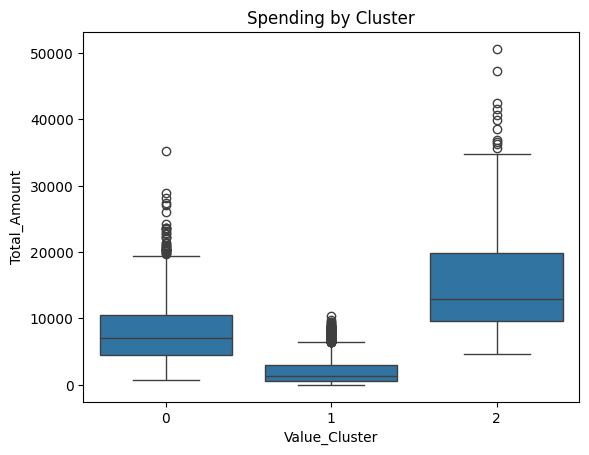

In [47]:
import seaborn as sns
sns.boxplot(x='Value_Cluster', y='Total_Amount', data=analysis_df)
plt.title('Spending by Cluster')
plt.show()

# Clustering Experiments Comparison and Analysis

You performed multiple clustering experiments using different preprocessing strategies, feature engineering approaches, scalers, and numbers of clusters. The main goal was to discover meaningful customer segments for customer value and customer engagement analysis.

---

# 1. Initial Clustering on the Full Dataset (17,049 Rows)

In the beginning, clustering was applied directly to the transactional dataset without grouping customers by `Customer_ID`.

## Results Before Log Transformation

| Number of Clusters | Silhouette Score |
| ------------------ | ---------------- |
| 4                  | 0.3164           |
| 5                  | 0.3259           |
| 6                  | 0.3334           |

### Analysis

The clustering quality improved slightly as the number of clusters increased. However, these results were still moderate because the dataset contained repeated customer transactions rather than customer-level behavior. This means the clustering algorithm was grouping transactions instead of identifying unique customer patterns.

---

## Results After Log Transformation

Log transformation was applied on:

* `Total_Amount`
* `Unit_Price`
* `Discount_Amount`

| Number of Clusters | Silhouette Score |
| ------------------ | ---------------- |
| 4                  | 0.1819           |
| 5                  | 0.1752           |

### Analysis

The performance became significantly worse after applying log transformation.

This indicates that the original data distribution already contained useful separations between customers, and applying logarithmic scaling reduced the natural variance that helped the clustering algorithm distinguish between groups.

The decrease in silhouette score shows that clusters became less separated and less compact after transformation.

---

# 2. Customer-Level Aggregation by Customer_ID

The next major improvement was aggregating the dataset by customer.

```python
customer_df = dataset.groupby('Customer_ID').agg({
    'Total_Amount':'sum',
    'Quantity':'sum',
    'Customer_Rating':'mean'
})
```

This reduced the dataset from:

* 17,049 transaction rows
  to
* 5,000 unique customers

---

## Results

| Number of Clusters | Silhouette Score |
| ------------------ | ---------------- |
| 4                  | 0.3541           |
| 5                  | 0.2872           |

### Analysis

This experiment produced better results than using the raw transactional dataset.

Why?

Because clustering customers is more meaningful than clustering transactions. Aggregation transformed the dataset into customer behavior profiles instead of isolated purchases.

The silhouette score improved to `0.3541`, indicating stronger cluster separation.

---

# 3. Expanded Customer Features Experiment

Additional behavioral and engagement features were added.

```python
customer_df = dataset.groupby('Customer_ID').agg({
    'Total_Amount':'sum',
    'Quantity':'sum',
    'Customer_Rating':'mean',
    'Delivery_Time_Days':'mean',
    'Session_Duration_Minutes':'mean',
    'Pages_Viewed':'mean',
    'Order_ID':'count'
})
```

Additional engineered feature:

```python
customer_df['Avg_Order_Value'] =
customer_df['Total_Amount'] / customer_df['Num_Orders']
```

---

## Results

| Number of Clusters | Silhouette Score | Davies-Bouldin | Calinski-Harabasz |
| ------------------ | ---------------- | -------------- | ----------------- |
| 2                  | 0.2872           | 1.4006         | 1639.06           |
| 3                  | 0.2246           | 1.3579         | 1427.27           |
| 5                  | 0.1568           | 1.6890         | 1064.74           |

### Analysis

Adding too many mixed behavioral features reduced clustering quality.

Reasons include:

* Some features may not strongly contribute to segmentation.
* Engagement and value behaviors may represent different customer dimensions.
* Combining all features together increased overlap between clusters.

This experiment showed that mixing all customer behaviors into a single clustering model reduced interpretability and cluster separation.

---

# 4. Separating Value and Engagement Clustering (Best Strategy)

This was the strongest and most meaningful experiment.

Instead of clustering all features together, I separated customer behavior into:

## Value Features

```python
customer_df = dataset.groupby('Customer_ID').agg({
    'Total_Amount':'sum',
    'Quantity':'sum',
    'Order_ID':'count'
})

customer_df['Avg_Order_Value']
```

These features measure:

* Customer spending
* Purchase frequency
* Order value

---

## Engagement Features

```python
engagement_df = dataset.groupby('Customer_ID').agg({
    'Session_Duration_Minutes':'mean',
    'Pages_Viewed':'mean',
    'Customer_Rating':'mean'
})
```

These features measure:

* Website interaction
* Browsing activity
* Customer satisfaction

---

# Best Results

## Value Clustering

| Scaler         | Number of Clusters | Silhouette | Davies-Bouldin | Calinski-Harabasz |
| -------------- | ------------------ | ---------- | -------------- | ----------------- |
| StandardScaler | 3                  | 0.5119     | 0.8929         | 3662.80           |
| RobustScaler   | 3                  | 0.4759     | 0.8993         | 3590.74           |

---

## Engagement Clustering

| Scaler         | Number of Clusters | Silhouette | Davies-Bouldin | Calinski-Harabasz |
| -------------- | ------------------ | ---------- | -------------- | ----------------- |
| RobustScaler   | 4                  | 0.2181     | 1.2297         | 1395.15           |
| StandardScaler | 4                  | 0.2162     | 1.2086         | 1399.47           |

---

# Why This Was the Best Approach

This strategy worked best because:

1. Customer value and customer engagement represent different behavioral dimensions.
2. Separating them reduced feature conflict.
3. The clustering algorithm could detect clearer patterns.
4. Customer purchasing behavior became highly separable.

The value clustering achieved a silhouette score above `0.5`, which is considered strong clustering quality.

---

# Meaning of the Final Result We Kept

The final selected solution was:

* Value clustering:

  * 3 clusters
  * StandardScaler

* Engagement clustering:

  * 4 clusters
  * RobustScaler

This created:

```text
3 Value Groups × 4 Engagement Groups = 12 Customer Segments
```

These segments provide a detailed customer segmentation framework.

---

# Final Revenue vs Engagement Grid

| Value Cluster | Meaning                |
| ------------- | ---------------------- |
| V0            | Medium-value customers |
| V1            | Low-value customers    |
| V2            | High-value customers   |

| Engagement Cluster | Meaning                  |
| ------------------ | ------------------------ |
| E0                 | Low engagement           |
| E1                 | Moderate engagement      |
| E2                 | Active engagement        |
| E3                 | Highly engaged customers |

---

# Final Segment Interpretation

| Segment | Meaning                             |
| ------- | ----------------------------------- |
| V2_E3   | High-value highly engaged customers |
| V2_E0   | High spenders with low interaction  |
| V1_E3   | Low spenders but highly engaged     |
| V0_E2   | Medium-value active customers       |
| V1_E0   | Low-value low-engagement customers  |

---

# Comparison Between All Main Experiments

| Experiment                               | Silhouette Score | Result Quality | Main Issue                        |
| ---------------------------------------- | ---------------- | -------------- | --------------------------------- |
| Full dataset without aggregation         | 0.33             | Moderate       | Transaction-level clustering      |
| Log-transformed data                     | 0.18             | Poor           | Lost natural variance             |
| Aggregated customer features             | 0.35             | Better         | Limited behavioral representation |
| All features combined                    | 0.22             | Weak           | Feature overlap/conflict          |
| Separate value and engagement clustering | 0.51             | Best           | Clear behavioral separation       |

---

# Key Insights

## 1. Customer-Level Aggregation Was Essential

Reducing the dataset from transactions to unique customers significantly improved clustering quality because customer behavior became more stable and meaningful.

---

## 2. Feature Engineering Strongly Influenced Performance

The engineered feature:

```python
Avg_Order_Value
```

helped distinguish between:

* frequent low spenders
* infrequent high spenders

This improved value segmentation quality.

---

## 3. Separating Value from Engagement Was the Most Important Decision

Combining all features together weakened clustering performance.

Separating:

* monetary behavior
  from
* engagement behavior

produced much clearer customer groups.

---

## 4. StandardScaler Worked Better for Value Features

Value-related variables benefited from standardization because spending behavior followed a wider numerical range.

---

## 5. RobustScaler Helped Engagement Features

Engagement metrics likely contained outliers and skewed browsing behavior, so RobustScaler handled them better.

---

# Business Interpretation of Final Segments

## High-Value Highly Engaged Customers (V2_E3)

These are the most important customers.

Characteristics:

* Highest spending
* Strong website interaction
* High customer ratings

Business strategy:

* Loyalty programs
* VIP offers
* Premium recommendations

---

## High-Value Low-Engagement Customers (V2_E0)

These customers spend heavily but interact less with the platform.

Possible interpretation:

* Goal-oriented buyers
* Fast purchasing behavior

Business strategy:

* Personalized retention campaigns
* Product recommendation emails

---

## Low-Value Highly Engaged Customers (V1_E3)

These customers interact heavily but spend less.

Possible interpretation:

* Interested but price-sensitive users

Business strategy:

* Discounts
* Upselling
* Bundles
* Personalized promotions

---

## Low-Value Low-Engagement Customers (V1_E0)

These are weak customers in both dimensions.

Business strategy:

* Re-engagement campaigns
* Special incentives
* Retargeting

---

# Final Conclusion

The final clustering framework successfully transformed raw transactional data into meaningful customer intelligence.

The best-performing solution was:

* Customer-level aggregation
* Feature engineering
* Separate clustering for value and engagement
* StandardScaler for value features
* RobustScaler for engagement features

This approach produced:

* Strong cluster separation
* Better interpretability
* Actionable business insights
* A scalable customer segmentation framework

The final 12 customer segments provide a complete understanding of customer purchasing power and engagement behavior, making the clustering solution highly useful for marketing, personalization, retention strategies, and business decision-making.
